<img src="images/banner.png" style="width: 100%;">

In [1]:
import numpy as np
import pandas as pd

# SVD and LSA

*References*

[1] C. Aggarwal, Data Mining: The Textbook, Chapter 2.

Adapted from notebooks of **Prof Christian Alis**, revised and edited by **Leodegario Lorenzo II**

## 1 Singular Value Decomposition

SVD decomposes an $n \times d$ matrix $\mathbf D$ into $\mathbf{D}=\mathbf{Q\Sigma P}^T$ where
* $\mathbf{Q}$ is an $n \times n$ matrix of orthonormal columns (left singular vectors)
* $\mathbf{\Sigma}$ is an $n \times d$ diagonal matrix of singular values
* $\mathbf{P}$ is a $d \times d$ matrix of orthonormal columns (right singular vectors).

Recall that for any matrix $\mathbf{M}$ with eigenvector matrix $\mathbf{V}$ and eigenvalue matrix $\mathbf{\Lambda}$,
$$
\mathbf{MV} = \mathbf{V \Lambda} \Rightarrow \mathbf{M} = \mathbf{V \Lambda V^{-1}}.
$$
With that, we can see that $\mathbf{Q}$ is the eigenvector of $\mathbf{DD}^T$,
$$
\begin{align}
\mathbf{DD}^T \mathbf{Q} &= (\mathbf{Q\Sigma P}^T)(\mathbf{Q\Sigma P}^T)^T\mathbf{Q} \\
    &= (\mathbf{Q\Sigma P}^T)(\mathbf{P \Sigma}^T \mathbf{Q}^T)\mathbf{Q} \\
    &= \mathbf{Q\Sigma} (\mathbf{P}^T \mathbf{P}) \mathbf{\Sigma}^T (\mathbf{Q}^T\mathbf{Q}) \\
    &= \mathbf{Q\Sigma} \mathbf{\Sigma}^T.
\end{align}
$$
The eigenvalues are $\mathbf{\Sigma \Sigma}^T$ which is the square of the singular values $\mathbf \Sigma$.

Similarly, $\mathbf{P}$ is the eigenvector of $\mathbf{D}^T\mathbf{D}$,
$$
\begin{align}
\mathbf{D}^T \mathbf{DP} &= (\mathbf{Q\Sigma P}^T)^T(\mathbf{Q\Sigma P}^T)\mathbf{P} \\
    &= (\mathbf{P \Sigma}^T \mathbf{Q}^T)(\mathbf{Q\Sigma P}^T)\mathbf{P} \\
    &= \mathbf{P \Sigma}^T (\mathbf{Q}^T \mathbf{Q}) \mathbf{\Sigma} (\mathbf{P}^T \mathbf{P}) \\
    &= \mathbf{P \Sigma}^T \mathbf{\Sigma}.
\end{align}
$$
The eigenvalues are $\mathbf{\Sigma}^T \mathbf{\Sigma}$, which is the square of the singular values $\mathbf \Sigma$.

The columns of $\mathbf{P}$ are basis vectors similar to principal components. In fact, since the covariance matrix is given by $\frac{\mathbf{X}^T \mathbf{X}}{n}$ where $\mathbf X$ is mean-centered, they match the principal components if $\mathbf{D} = \mathbf{X}$. In that case, the $i$th PCA eigenvalue is given by $\lambda_i = \sigma_i^2/n$. In general, the square of the singular values correspond to the sum of square distance from the origin.

To reduce the number of dimensions to $k$, we truncate $\mathbf{Q}$, $\mathbf{\Sigma}$ and $\mathbf{P}$ into $n \times k$, $k \times k$ and $d \times k$ matrices, respectively, as shown below. This is known as a truncated SVD.

<div style="text-align: center">
<img src="images/truncated.png" style="width: 30em" />

Figure from C. Aggarwal, Data Mining: The Textbook
</div>

The truncated dataset $\mathbf D_k$ can then be computed using $\mathbf{D_k} = \mathbf{D P_k} = \mathbf{Q_k \Sigma_k}$.

## 2 Applied Example: `TruncatedSVD` on the Cars Dataset 

We again use the `Cars` dataset for illustration.

In [2]:
from sklearn.datasets import fetch_openml

### Data Loading

In [3]:
data = fetch_openml(data_id=455, parser='auto')

In [4]:
print(data.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

The Committee on Statistical Graphics of the American Statistical
Association (ASA) invites you to participate in its Second (1983)
Exposition of Statistical Graphics Technology. The purposes of the
Exposition are (l) to provide a forum in which users and providers of
statistical graphics technology can exchange information and ideas and
(2) to expose those members of the ASA community who are less familiar
with statistical graphics to its capabilities and potential benefits
to them. The Exposition wil1 be held in conjunction with the Annual
Meetings in Toronto, August 15-18, 1983 and is tentatively scheduled
for the afternoon of Wednesday, August 17.

Seven providers of statistical graphics technology participated in the
l982 Exposition. By all accounts, the Exposition was well received by
the ASA community and was a worthwhile experience for the
participants. We hope to have those seven involved again this year,

### Data Preprocessing

We remove the model year and rows with null values. We also standardize the features but you should also try to observe what happens if you run PCA without standardizing first.

In [5]:
X = (data
     .data.drop('model.year', axis=1)
     .dropna()
     .astype(float))
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0)) # Min-Max Normalization

### SVD Computation

Let us compute the SVD decomposition of the data matrix using [`TruncatedSVD`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html)

In [6]:
from sklearn.decomposition import TruncatedSVD

In [7]:
svd = TruncatedSVD(n_components=X.shape[1])
svd.fit(X)

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",6
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",5
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0


In [8]:
svd.components_ # Right Singular Vectors^T

array([[ 0.28981271,  0.56189805,  0.38647138,  0.35006808,  0.42916813,
         0.37971847],
       [ 0.67305985, -0.29191824, -0.29296686, -0.16969101, -0.16937541,
         0.56432396],
       [-0.6251938 , -0.04686648, -0.05293602, -0.34310213,  0.22787459,
         0.65915713],
       [ 0.0830567 ,  0.6734248 ,  0.01093547, -0.61059234, -0.40513587,
        -0.05022913],
       [-0.24837109,  0.27111273, -0.39289906,  0.59645319, -0.54074684,
         0.24955255],
       [-0.05954107, -0.26430056,  0.77943493,  0.04856776, -0.52788034,
         0.19510198]])

In [9]:
svd.singular_values_ # sigma

array([20.47870773,  8.95235605,  2.79689577,  2.03663804,  1.21142969,
        1.03231603])

In [10]:
energy = (svd.singular_values_)**2 # Preserved energy
energy

array([419.37747032,  80.14467885,   7.82262592,   4.14789451,
         1.4675619 ,   1.06567638])

In [11]:
energy_ratio = energy / energy.sum()
energy_ratio

array([0.81586835, 0.15591564, 0.01521835, 0.00806943, 0.00285503,
       0.0020732 ])

### Choosing the Number of Singular Vectors

To choose the number of singular vectors, you have several ways to do so, we demonstrate the different methods below

In [12]:
X_transformed = svd.transform(X)

In [13]:
from utils import plot_energy_ratio

#### Cumulative Energy Preserved

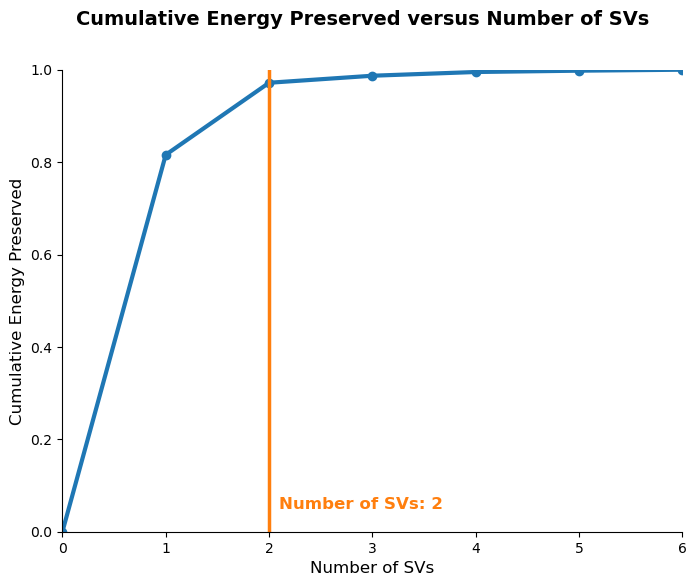

In [14]:
plot_energy_ratio(energy_ratio);

#### Explained Variance

In [15]:
svd.explained_variance_ # Explained variance of each SV

array([0.14224736, 0.18121348, 0.01992391, 0.01055731, 0.00373695,
       0.00271853])

In [16]:
np.var(X_transformed, axis=0) # svd.explained_variance_ is similar to this

array([0.14224736, 0.18121348, 0.01992391, 0.01055731, 0.00373695,
       0.00271853])

In [17]:
exp_var_ratio = svd.explained_variance_ratio_
exp_var_ratio

array([0.39469571, 0.50281551, 0.05528315, 0.02929351, 0.01036896,
       0.00754316])

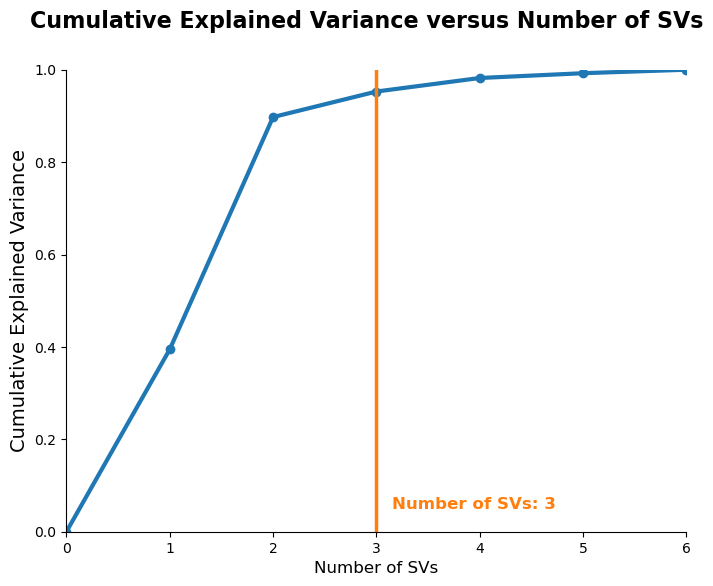

In [18]:
fig, ax, thresh = plot_energy_ratio(exp_var_ratio)
ax.set_ylabel('Cumulative Explained Variance', fontsize=14)
fig.suptitle("Cumulative Explained Variance versus Number of SVs", fontsize=16,
             weight='bold');

#### Reconstruction Error

We can compute the reconstruction error by recovering **$D$** as $\widetilde{D}$ from the transformed vectors:

$$
D_k' = DV_k = U_k \Sigma_k
$$

$$
\widetilde{D} = D_k' V^T
$$

Afterwards we can compute the reconstruction error using any metric as:

$$
\text{Reconstruction Error} = \frac{1}{N} \sum_{ij} || D_{ij} - \widetilde{D}_{ij} ||
$$

In [19]:
from sklearn.metrics import mean_squared_error

In [20]:
def compute_reconstruction_error(X, X_transformed, v_T, metric=mean_squared_error):
    reconstruction_error = [
        metric(X, (X_transformed[:, :i] @ v_T[:i, :]))
        for i in range(1, X_transformed.shape[1] + 1)
    ]

    return np.array(reconstruction_error)

In [21]:
reconstruction_error = compute_reconstruction_error(X.to_numpy(), X_transformed, svd.components_)
reconstruction_error

array([4.02416826e-02, 6.16656408e-03, 2.84061768e-03, 1.07705709e-03,
       4.53093701e-04, 1.06428740e-32])

In [22]:
from utils import plot_reconstruction_error

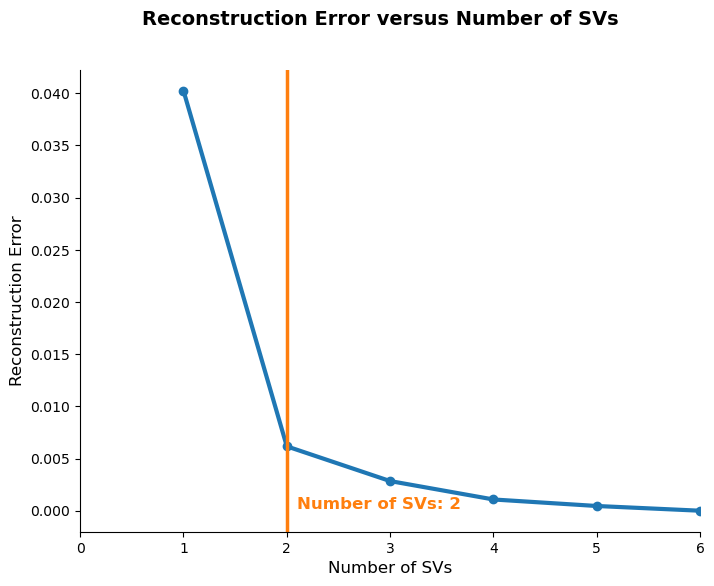

In [23]:
plot_reconstruction_error(reconstruction_error);

### Transforming the Original Feature Vectors

After the number of SVs has been selected, the truncation is straightforward:

In [24]:
thresh = 2
X_truncated = X_transformed[:, :thresh]

### Interpreting the SVs

We use a familiar function to interpret the Singular Vectors

In [25]:
from utils import plot_principal_components

In [26]:
W = pd.DataFrame(svd.components_, columns=X.columns,
                 index=[f'SV {i + 1}' for i in range(X.shape[1])])
W

,mpg,cylinders,displacement,horsepower,weight,acceleration
SV 1,0.289813,0.561898,0.386471,0.350068,0.429168,0.379718
SV 2,0.673060,-0.291918,-0.292967,-0.169691,-0.169375,0.564324
SV 3,-0.625194,-0.046866,-0.052936,-0.343102,0.227875,0.659157
SV 4,0.083057,0.673425,0.010935,-0.610592,-0.405136,-0.050229
SV 5,-0.248371,0.271113,-0.392899,0.596453,-0.540747,0.249553
SV 6,-0.059541,-0.264301,0.779435,0.048568,-0.527880,0.195102


In [27]:
X_transformed = pd.DataFrame(X_transformed, columns=W.index)
X_transformed

,SV 1,SV 2,SV 3,SV 4,SV 5,SV 6
0,1.350263,-0.345657,-0.106722,0.192137,0.010809,-0.011594
1,1.448366,-0.490060,-0.135392,0.050365,0.064022,0.054905
2,1.368422,-0.402754,-0.189149,0.136880,0.060044,0.014404
3,1.361263,-0.394222,-0.114938,0.129422,0.102783,0.001437
4,1.315991,-0.416739,-0.170464,0.167405,0.041058,-0.026629
...,...,...,...,...,...,...
387,0.714119,0.371198,-0.018870,-0.114178,-0.075673,-0.013694
388,0.860635,1.073426,0.078222,0.083890,-0.019649,0.067108
389,0.593218,0.355738,-0.286517,-0.027819,-0.093634,-0.004577
390,0.736266,0.519390,0.087338,-0.079322,-0.014805,0.002129


In [28]:
W.max().max()

np.float64(0.779434933519061)

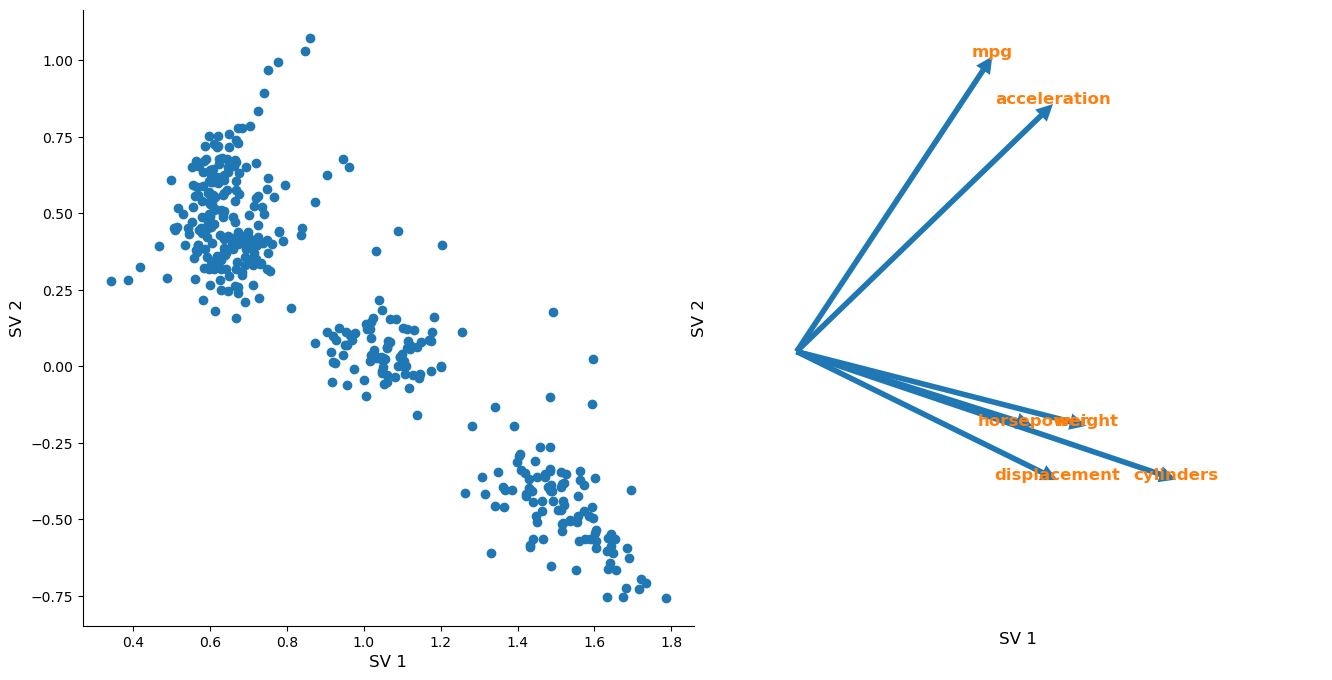

In [29]:
fig, axes = plot_principal_components(X_transformed, W, 'SV 1', 'SV 2')
axes[1].set_ylim(W.min().min(), W.max().max())
axes[1].set_xlim(W.min().min() + 0.5, W.max().max());

## 3 Latent Semantic Analysis

One advantage of Truncated SVD over PCA is that SVD does not require the dataset to be mean-centered. This is desirable for sparse datasets wherein mean-centering them could lead to dense matrices unless the mean is already zero. Bag-of-words and TF-IDF matrices are usually sparse so Truncated SVD is typically used on them instead of PCA. In that case, the process is known as Latent Semantic Analysis (LSA).

Let us perform latent semantic analysis on the newsgroups dataset.

In [30]:
from sklearn.datasets import fetch_20newsgroups

data_newsgroups = fetch_20newsgroups(
    subset="all",
    categories=["comp.graphics", "rec.autos"],
    shuffle=False,
    remove=("headers", "footers", "quotes"),
)

# Remove documents comprising only an empty string
docs, target = zip(
    *[
        (doc, target)
        for doc, target in zip(
            data_newsgroups["data"], data_newsgroups["target"]
        )
        if doc.strip()
    ]
)

docs = np.array(docs)
target = np.array(target)

### Data Preparation

In [31]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r'\w+',
    stop_words=stopwords.words('english'),
    lowercase=True,
    min_df=5
)
tfidf_vectorizer.fit(docs)
df_tfidf = pd.DataFrame.sparse.from_spmatrix(
    tfidf_vectorizer.transform(docs),
    columns=tfidf_vectorizer.get_feature_names_out(),
)

In [33]:
df_tfidf

,0,00,000,01,02,03,04,05,06,09,...,young,yr,yuv,z,zealand,zero,zip,zoom,zooming,zyxel
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1887,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1888,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1889,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1890,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Performing SVD

In [34]:
svd_ng = TruncatedSVD(n_components=df_tfidf.shape[1])
svd_ng.fit(df_tfidf)

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",4592
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",5
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0


### Choosing the Number of Singular Vectors

In [35]:
semantic_vectors = svd_ng.transform(df_tfidf)

In [36]:
energy_ng = (svd_ng.singular_values_)**2
energy_ratio_ng = energy_ng / energy_ng.sum()
energy_ratio_ng

array([2.26222686e-02, 9.08917194e-03, 5.61906477e-03, ...,
       1.55024585e-36, 9.51549304e-37, 5.70839713e-41], shape=(1892,))

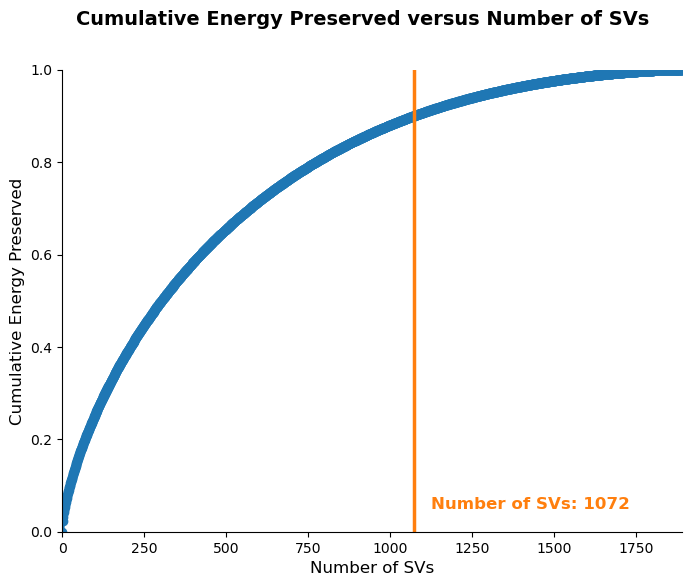

In [37]:
fig, ax, thresh = plot_energy_ratio(energy_ratio_ng);

### Data Reduction

In [38]:
truncated_semantic_vectors = semantic_vectors[:, :thresh]
truncated_semantic_vectors

array([[ 0.06429876,  0.07482418,  0.0083235 , ..., -0.00794649,
        -0.00764514, -0.01540148],
       [ 0.23221084,  0.12154604,  0.04755927, ...,  0.00917475,
         0.00032212, -0.00633401],
       [ 0.08759708,  0.11146704,  0.01991115, ...,  0.01611518,
        -0.03068253,  0.02300497],
       ...,
       [ 0.1409446 ,  0.12812934,  0.0243405 , ..., -0.00709065,
         0.01612329, -0.00109745],
       [ 0.16630778, -0.09567427, -0.00494102, ..., -0.02236523,
        -0.00135296, -0.01054357],
       [ 0.10964755,  0.07815583, -0.02968659, ..., -0.01554895,
        -0.02083402,  0.00348222]], shape=(1892, 1072))

## Interpreting the Singular Vectors

In [39]:
W_ng = pd.DataFrame(svd_ng.components_, columns=df_tfidf.columns,
                 index=[f'SV {i + 1}' for i in range(df_tfidf.shape[0])])
W_ng

,0,00,000,01,02,03,04,05,06,09,...,young,yr,yuv,z,zealand,zero,zip,zoom,zooming,zyxel
SV 1,0.080752,0.020316,0.026142,0.003994,0.004335,0.005379,0.002122,0.001099,0.001888,0.002539,...,0.001291,0.002614,0.001978,0.027643,0.002706,0.002398,0.017665,0.001655,0.001273,0.001527
SV 2,-0.049832,0.004479,0.039695,-0.002377,0.003773,-0.004151,-0.000604,-0.001627,-0.001219,-0.000719,...,-0.000325,0.003383,-0.002937,-0.029014,-0.001549,0.002101,-0.030673,-0.002504,-0.001465,-0.001758
SV 3,-0.264746,-0.018968,-0.002576,-0.006050,-0.004131,-0.001551,-0.002241,-0.001885,-0.002613,-0.004884,...,-0.001567,-0.000737,-0.002969,-0.089742,0.000996,-0.003648,0.003520,-0.002546,-0.001808,-0.000187
SV 4,0.130077,0.014789,-0.002438,0.002394,0.002447,-0.005218,-0.001694,-0.000081,0.001126,0.003027,...,0.001648,0.000431,0.001381,0.051833,0.004927,0.001529,-0.016849,-0.000909,0.001838,0.001336
SV 5,-0.290015,-0.026146,-0.013518,-0.011172,0.002005,-0.004081,0.000547,0.000844,0.000176,-0.001600,...,0.002792,0.000630,-0.008556,-0.066047,-0.000728,-0.005644,-0.003139,0.000417,0.000594,0.002673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SV 1888,0.013019,0.013671,-0.002168,-0.020542,0.040120,-0.033024,0.048631,-0.025969,0.002206,-0.010282,...,-0.005046,-0.001816,0.007677,-0.008935,0.009309,-0.008482,0.003500,-0.000446,0.002856,-0.000821
SV 1889,0.015430,-0.029233,-0.032587,-0.002674,0.025877,0.037867,-0.047076,0.075953,0.002827,-0.016736,...,0.001820,-0.000353,-0.006596,-0.006791,0.007086,-0.001013,0.012390,-0.007767,0.001013,0.000858
SV 1890,0.000264,-0.013882,0.015965,0.058931,0.000275,0.029407,-0.038734,-0.000224,0.010420,0.008250,...,0.003283,-0.016887,0.002168,0.010421,0.008011,0.000038,-0.002577,0.003859,0.001014,-0.002539
SV 1891,0.006228,0.003176,-0.002091,-0.060911,0.031641,-0.030499,-0.051950,0.003366,-0.003780,0.043514,...,-0.006135,-0.004736,0.002722,0.006682,-0.001955,0.010731,0.001466,0.004281,-0.000057,0.003116


In [40]:
semantic_vectors = pd.DataFrame(semantic_vectors, columns=W_ng.index)
semantic_vectors

,SV 1,SV 2,SV 3,SV 4,SV 5,SV 6,SV 7,SV 8,SV 9,SV 10,...,SV 1883,SV 1884,SV 1885,SV 1886,SV 1887,SV 1888,SV 1889,SV 1890,SV 1891,SV 1892
0,0.064299,0.074824,0.008324,-0.017781,-0.008388,-0.019429,0.048146,-0.010780,0.023733,0.033819,...,1.527221e-18,1.644884e-18,8.198016e-19,6.161379e-19,-2.796332e-18,-5.579008e-19,-8.037465e-19,-8.379408e-19,1.264500e-18,-4.953028e-19
1,0.232211,0.121546,0.047559,-0.027327,0.056397,-0.004527,-0.023903,-0.037873,-0.014604,-0.009914,...,-2.894886e-17,1.800769e-18,1.240043e-17,-2.629983e-17,9.682259e-18,1.464167e-17,5.166693e-17,2.550951e-17,-1.867876e-17,-1.565481e-17
2,0.087597,0.111467,0.019911,-0.024225,-0.005374,-0.010894,0.073112,-0.030553,0.081972,0.083305,...,-5.138719e-17,-4.891131e-17,1.221381e-17,5.456167e-18,-9.586238e-18,3.779602e-17,2.058487e-17,1.179522e-17,-4.752336e-17,-4.312646e-18
3,0.165399,0.004259,-0.089729,-0.015502,-0.014835,0.066486,-0.007855,0.044806,-0.015662,-0.033154,...,7.461644e-17,2.258756e-17,-1.043583e-17,-2.752300e-17,9.693039e-18,-5.574734e-18,1.728795e-18,1.774839e-17,-2.606743e-19,-4.740505e-17
4,0.076241,0.056986,0.032296,0.007251,-0.007236,-0.032924,0.045323,-0.008973,0.041493,0.022083,...,-5.128750e-18,1.864340e-17,-1.512989e-17,-9.411658e-18,1.287064e-17,-3.357521e-17,2.039442e-17,9.936823e-18,-1.040404e-17,-2.372903e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1887,0.092814,0.089507,-0.017350,-0.008414,-0.008923,-0.014476,0.003168,-0.001056,0.020598,-0.010598,...,-9.659574e-18,-3.021859e-17,2.109122e-17,8.997648e-18,5.350636e-17,-8.603464e-18,1.738598e-17,1.902481e-17,1.736581e-17,2.605100e-17
1888,0.148344,-0.126251,-0.010498,-0.262803,-0.022852,-0.071875,-0.070548,0.147353,0.095824,0.015435,...,-1.112989e-17,1.641483e-18,1.700619e-17,-1.134100e-17,1.705016e-17,2.184061e-17,-6.136851e-18,-2.038846e-17,1.853619e-17,3.253958e-17
1889,0.140945,0.128129,0.024340,-0.028424,0.018108,-0.008705,0.001056,-0.006814,-0.004340,0.005104,...,1.218213e-17,3.508331e-17,-3.788692e-18,5.944153e-18,-1.951354e-17,-5.023249e-18,-5.690043e-17,1.656536e-17,5.498644e-18,2.280486e-17
1890,0.166308,-0.095674,-0.004941,-0.142666,0.012241,-0.005828,-0.022154,-0.036090,-0.028502,0.020124,...,-3.409937e-18,1.341269e-17,-7.294901e-18,-6.864608e-18,-5.243354e-17,2.627099e-17,1.761402e-17,3.962985e-17,-3.936415e-17,-4.052109e-18


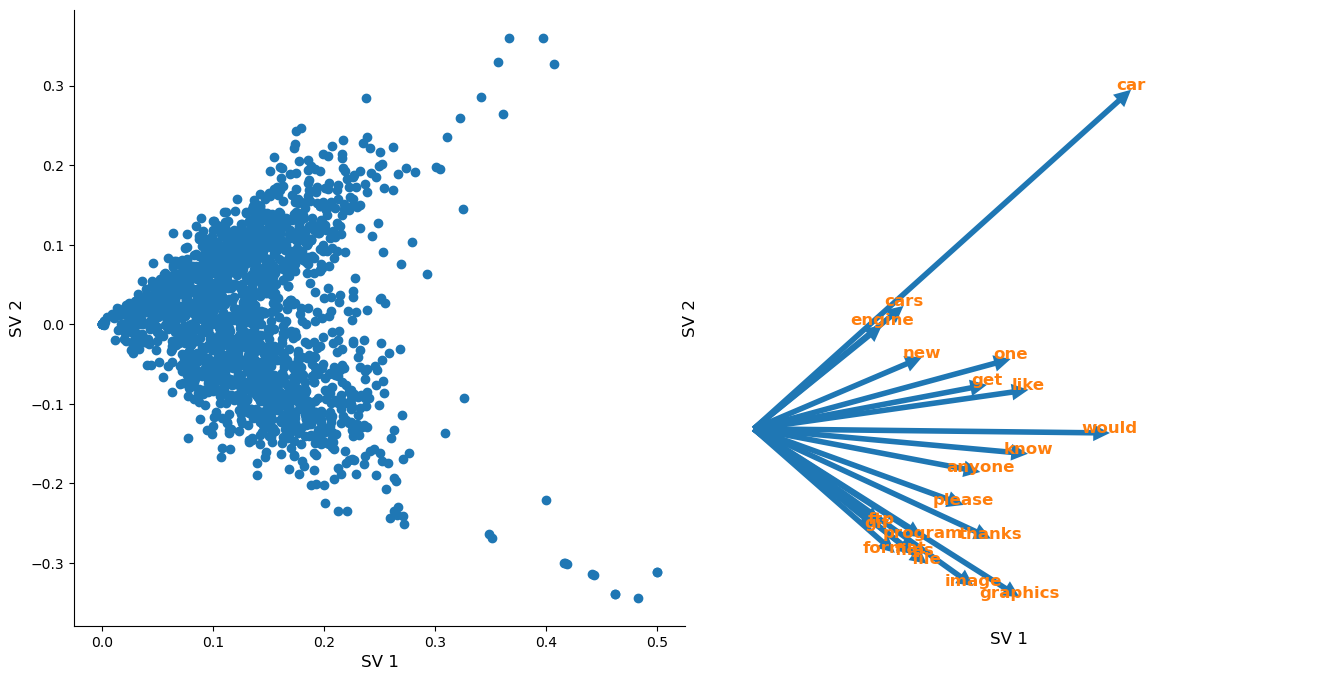

In [41]:
fig, axes = plot_principal_components(semantic_vectors, W_ng, 'SV 1', 'SV 2')
axes[1].set_ylim(W.min().min() + 0.4, W.max().max() - 0.3)
axes[1].set_xlim(W.min().min() + 0.6, W.max().max() - 0.5);

In [42]:
term_topic_matrix = pd.DataFrame(
    svd_ng.components_.T,
    index=df_tfidf.columns,
    columns=[f'SV {i + 1}' for i in range(df_tfidf.shape[0])])
term_topic_matrix

,SV 1,SV 2,SV 3,SV 4,SV 5,SV 6,SV 7,SV 8,SV 9,SV 10,...,SV 1883,SV 1884,SV 1885,SV 1886,SV 1887,SV 1888,SV 1889,SV 1890,SV 1891,SV 1892
0,0.080752,-0.049832,-0.264746,0.130077,-0.290015,-0.016446,-0.162226,0.034664,0.164446,-0.019854,...,-0.008968,-0.011348,-0.007205,-0.000307,0.005041,0.013019,0.015430,0.000264,0.006228,0.008866
00,0.020316,0.004479,-0.018968,0.014789,-0.026146,-0.022975,0.030981,0.004143,0.013893,0.017534,...,-0.027639,-0.012240,-0.006312,0.014910,0.022625,0.013671,-0.029233,-0.013882,0.003176,-0.013714
000,0.026142,0.039695,-0.002576,-0.002438,-0.013518,0.007208,0.013164,0.006609,-0.020881,-0.000021,...,-0.022556,-0.005383,0.002301,-0.008661,0.011513,-0.002168,-0.032587,0.015965,-0.002091,0.017927
01,0.003994,-0.002377,-0.006050,0.002394,-0.011172,-0.003100,-0.011397,0.004104,-0.006912,0.011056,...,-0.027909,-0.029288,0.032102,0.004961,-0.025578,-0.020542,-0.002674,0.058931,-0.060911,0.012926
02,0.004335,0.003773,-0.004131,0.002447,0.002005,0.000676,-0.003122,-0.000887,0.010197,-0.005841,...,0.003736,-0.014859,0.007546,-0.016110,0.026142,0.040120,0.025877,0.000275,0.031641,0.057755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zero,0.002398,0.002101,-0.003648,0.001529,-0.005644,0.000057,0.002021,-0.002042,0.002168,0.007273,...,-0.004595,0.010767,0.006401,-0.001820,0.009447,-0.008482,-0.001013,0.000038,0.010731,0.002659
zip,0.017665,-0.030673,0.003520,-0.016849,-0.003139,-0.047585,0.014849,0.080323,0.025578,0.008965,...,-0.004849,0.001277,0.005112,-0.004160,-0.010396,0.003500,0.012390,-0.002577,0.001466,0.006071
zoom,0.001655,-0.002504,-0.002546,-0.000909,0.000417,0.001176,0.006144,-0.003431,-0.003691,-0.001922,...,-0.001958,0.001127,0.001446,-0.005292,0.002953,-0.000446,-0.007767,0.003859,0.004281,0.003638
zooming,0.001273,-0.001465,-0.001808,0.001838,0.000594,0.001765,0.000651,0.000782,-0.000806,0.001137,...,-0.006019,-0.001967,0.001836,0.007079,-0.000902,0.002856,0.001013,0.001014,-0.000057,-0.001272


In [43]:
from utils import plot_topic_vector

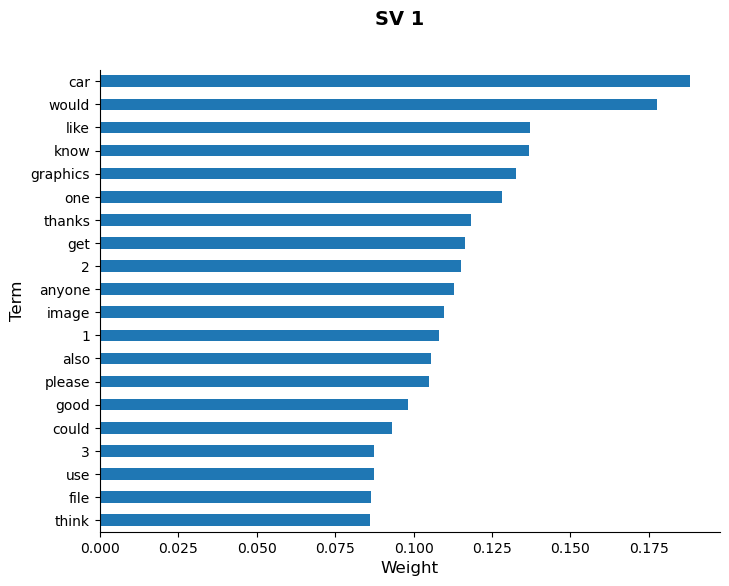

In [44]:
plot_topic_vector(term_topic_matrix, 'SV 1');

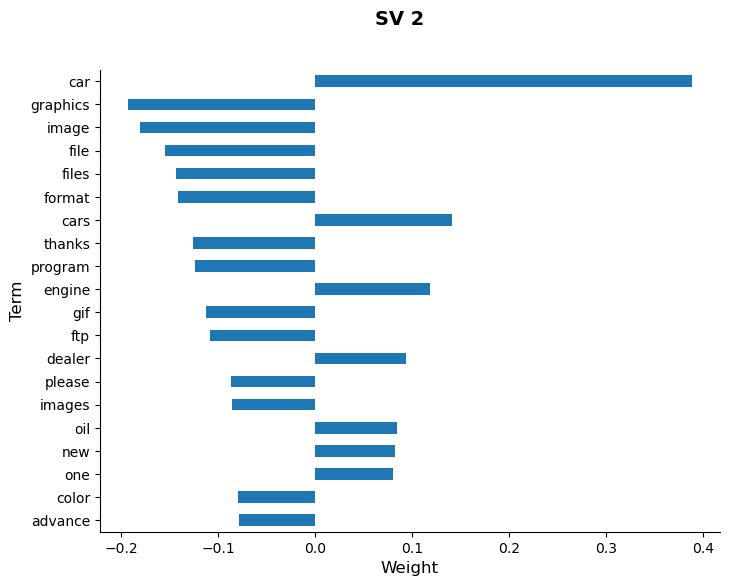

In [45]:
plot_topic_vector(term_topic_matrix, 'SV 2');

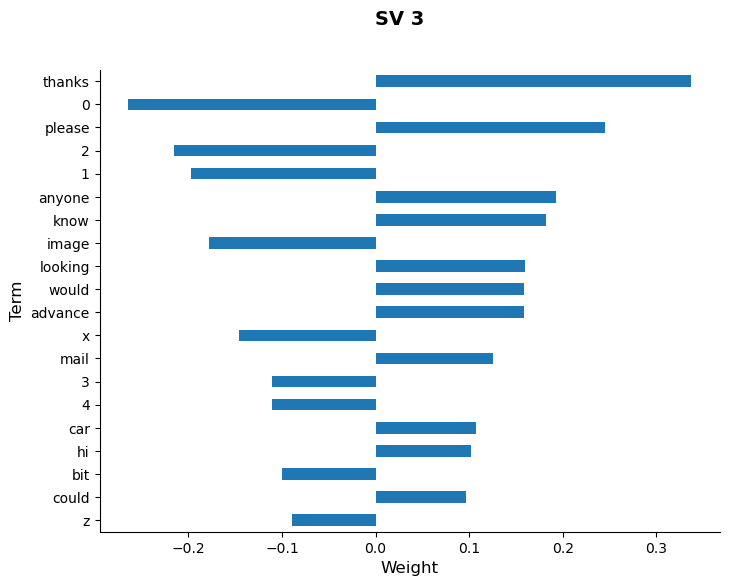

In [46]:
plot_topic_vector(term_topic_matrix, 'SV 3');

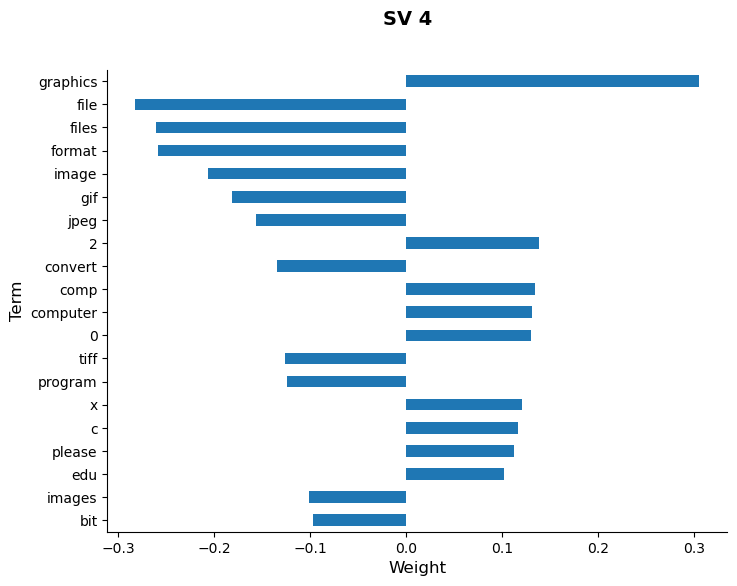

In [47]:
plot_topic_vector(term_topic_matrix, 'SV 4');

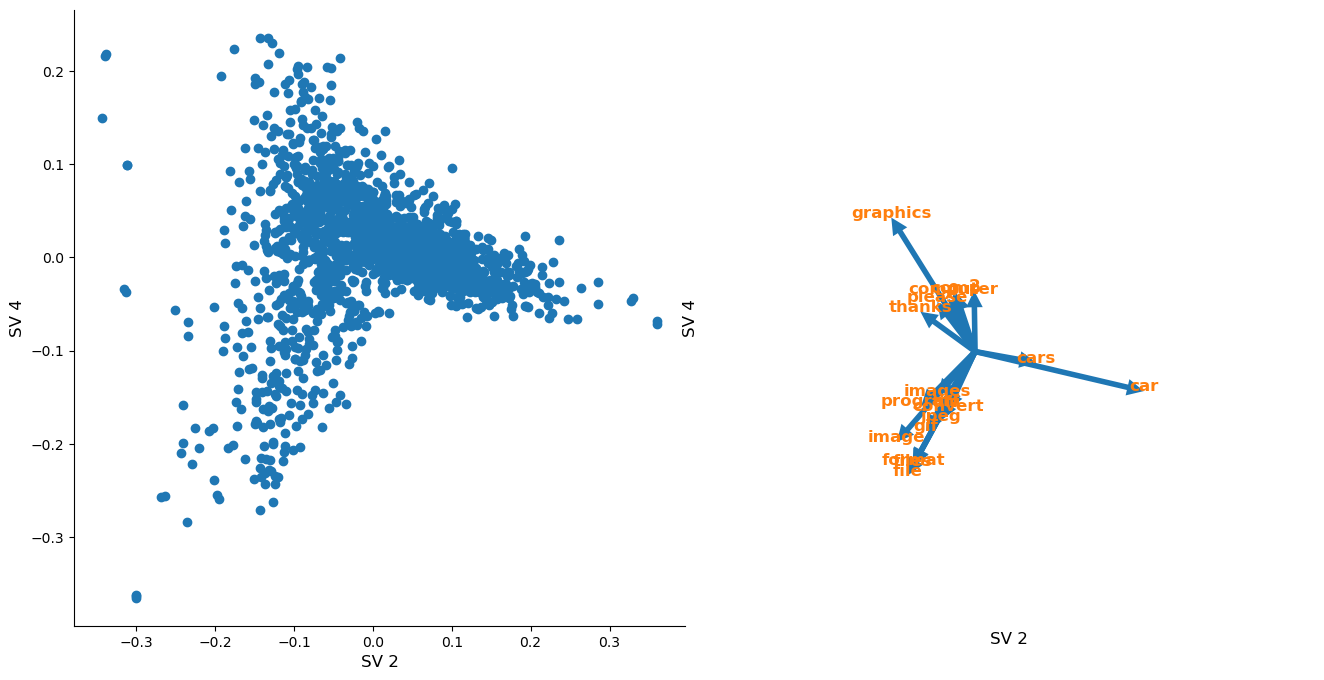

In [49]:
fig, axes = plot_principal_components(semantic_vectors, W_ng, 'SV 2', 'SV 4')
axes[1].set_ylim(W.min().min(), W.max().max())
axes[1].set_xlim(W.min().min(), W.max().max());

<img src="images/banner-down.png" style="width: 100%;">